# Capstone Three: Modeling
**Dataset:** Medical Cost  
**Response variable:** `annual_medical_cost` — *continuous* → **Regression problem**  
**Goal:** Build, tune, and compare three regression models; select the best one.

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Tuning & evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

SEED = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Preprocessed Train / Test Splits

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()   # Series
y_test  = pd.read_csv('y_test.csv').squeeze()

# Cast bool columns to int so all models accept them without warnings
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train mean: ${y_train.mean():,.0f}  |  y_test mean: ${y_test.mean():,.0f}')
X_train.head(3)

X_train: (4000, 22)  |  X_test: (1000, 22)
y_train mean: $8,057  |  y_test mean: $8,016


,age,bmi,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,...,heart_disease,asthma,gender_Male,smoker_Yes,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_None,insurance_type_Private,city_type_Semi-Urban,city_type_Urban
0,0.954285,0.283222,-1.280250,0.077507,1.218732,-1.507395,-0.001022,1.086591,0.665527,0.275438,...,0,0,1,0,0,0,0,1,0,1
1,-0.014483,-0.687816,-0.294496,-1.377576,1.218732,1.476955,-1.023028,0.214177,0.633906,-0.763042,...,1,0,0,0,1,0,0,1,1,0
2,-0.062921,-0.212206,-0.105194,1.047563,-0.164383,1.476955,1.020984,1.086591,0.855252,0.834496,...,0,0,0,0,0,0,0,1,1,0


## 3. Modeling Decisions

| Question | Answer |
|---|---|
| Time series / forecasting? | No — cross-sectional data; standard random split is appropriate |
| Response variable type? | Continuous (`annual_medical_cost`) → **Regression** |
| Models chosen | Linear Regression (baseline), Random Forest, Gradient Boosting |
| Evaluation metrics | MAE, RMSE, R², MAPE |
| Hyperparameter tuning | GridSearchCV with 5-fold cross-validation (RF & GB) |

**Why these three models?**
- **Linear Regression / Ridge** — Fast, interpretable baseline. Ridge adds L2 regularization to handle any multicollinearity.
- **Random Forest** — Handles non-linear relationships and feature interactions; robust to outliers.
- **Gradient Boosting** — Often achieves top accuracy on tabular data by correcting residual errors sequentially.

---

## 4. Evaluation Helper

A single function computes all metrics consistently across models.

In [3]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Fit, cross-validate, and test a model. Returns a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # CV score on training set (negative MSE → positive RMSE)
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_tr, y_tr,
        scoring='neg_mean_squared_error', cv=cv
    ))

    metrics = {
        'Model':        name,
        'CV RMSE (mean)': cv_rmse.mean(),
        'CV RMSE (std)':  cv_rmse.std(),
        'Test MAE':     mean_absolute_error(y_te, y_pred),
        'Test RMSE':    np.sqrt(mean_squared_error(y_te, y_pred)),
        'Test R²':      r2_score(y_te, y_pred),
        'Test MAPE':    mean_absolute_percentage_error(y_te, y_pred),
    }
    return metrics, y_pred

results = []   # will collect one dict per model
predictions = {}  # name -> y_pred array
print('Helper defined.')

Helper defined.


---
## 5. Model 1 — Ridge Regression (Baseline)

Linear regression with L2 regularization. Fast and interpretable — sets our performance floor.

In [4]:
# Hyperparameter tuning: search over alpha (regularization strength)
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_gs = GridSearchCV(
    Ridge(), ridge_params,
    scoring='neg_mean_squared_error', cv=5, n_jobs=-1
)
ridge_gs.fit(X_train, y_train)

print(f'Best alpha: {ridge_gs.best_params_["alpha"]}')
best_ridge = ridge_gs.best_estimator_

Best alpha: 1.0


In [5]:
m, p = evaluate('Ridge Regression', best_ridge, X_train, y_train, X_test, y_test)
results.append(m)
predictions['Ridge Regression'] = p

print(f"Test R²  : {m['Test R²']:.4f}")
print(f"Test RMSE: ${m['Test RMSE']:,.2f}")
print(f"Test MAE : ${m['Test MAE']:,.2f}")
print(f"Test MAPE: {m['Test MAPE']*100:.2f}%")

Test R²  : 0.9119
Test RMSE: $2,073.16
Test MAE : $1,382.88
Test MAPE: 34.44%


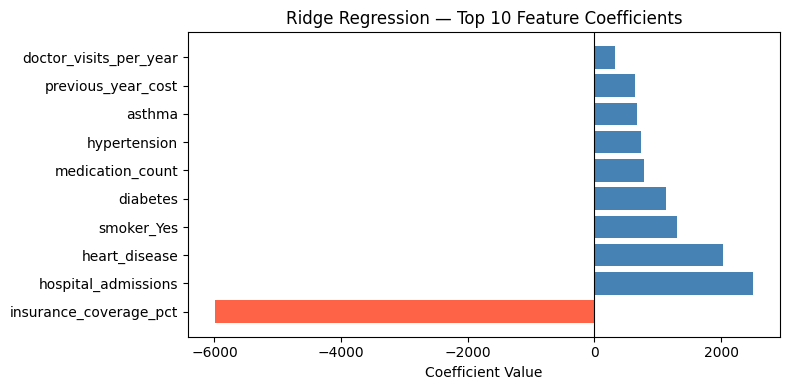

In [6]:
# Top 10 feature coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
}).reindex(pd.Series(best_ridge.coef_).abs().sort_values(ascending=False).index)
coef_df = coef_df.head(10)

plt.figure(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Ridge Regression — Top 10 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## 6. Model 2 — Random Forest Regressor

An ensemble of decision trees. Captures non-linear interactions and is robust to outliers.

In [7]:
# Hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    rf_params,
    scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)

print('Best params:', rf_gs.best_params_)
best_rf = rf_gs.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [8]:
m, p = evaluate('Random Forest', best_rf, X_train, y_train, X_test, y_test)
results.append(m)
predictions['Random Forest'] = p

print(f"Test R²  : {m['Test R²']:.4f}")
print(f"Test RMSE: ${m['Test RMSE']:,.2f}")
print(f"Test MAE : ${m['Test MAE']:,.2f}")
print(f"Test MAPE: {m['Test MAPE']*100:.2f}%")

Test R²  : 0.9790
Test RMSE: $1,010.96
Test MAE : $626.93
Test MAPE: 9.39%


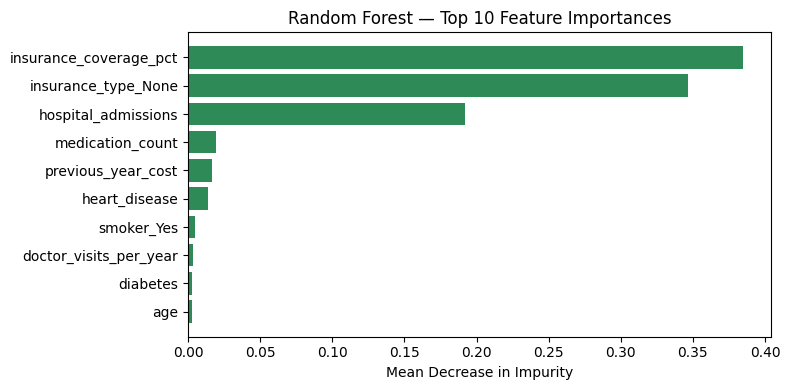

In [9]:
# Feature importance
fi_df = pd.DataFrame({
    'Feature':   X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='seagreen')
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Model 3 — Gradient Boosting Regressor

Builds trees sequentially, each correcting the residuals of the last. Often the strongest performer on tabular data.

In [10]:
# Hyperparameter tuning
gb_params = {
    'n_estimators':   [100, 200],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [3, 5],
}
gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    gb_params,
    scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=0
)
gb_gs.fit(X_train, y_train)

print('Best params:', gb_gs.best_params_)
best_gb = gb_gs.best_estimator_

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [11]:
m, p = evaluate('Gradient Boosting', best_gb, X_train, y_train, X_test, y_test)
results.append(m)
predictions['Gradient Boosting'] = p

print(f"Test R²  : {m['Test R²']:.4f}")
print(f"Test RMSE: ${m['Test RMSE']:,.2f}")
print(f"Test MAE : ${m['Test MAE']:,.2f}")
print(f"Test MAPE: {m['Test MAPE']*100:.2f}%")

Test R²  : 0.9958
Test RMSE: $453.75
Test MAE : $274.87
Test MAPE: 5.13%


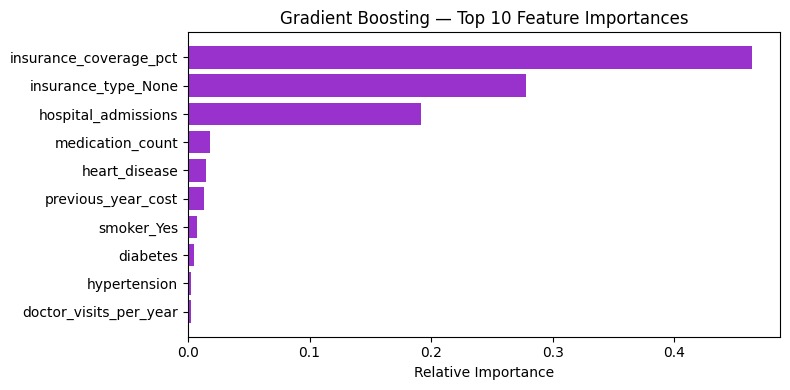

In [12]:
# Feature importance
fi_gb = pd.DataFrame({
    'Feature':   X_train.columns,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.barh(fi_gb['Feature'], fi_gb['Importance'], color='darkorchid')
plt.title('Gradient Boosting — Top 10 Feature Importances')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Model Comparison

### 8a. Metrics Table

In [13]:
results_df = pd.DataFrame(results).set_index('Model')

# Format for display
display_df = results_df.copy()
display_df['CV RMSE (mean)'] = display_df['CV RMSE (mean)'].map('${:,.0f}'.format)
display_df['CV RMSE (std)']  = display_df['CV RMSE (std)'].map('${:,.0f}'.format)
display_df['Test MAE']       = display_df['Test MAE'].map('${:,.0f}'.format)
display_df['Test RMSE']      = display_df['Test RMSE'].map('${:,.0f}'.format)
display_df['Test R²']        = display_df['Test R²'].map('{:.4f}'.format)
display_df['Test MAPE']      = display_df['Test MAPE'].map('{:.2%}'.format)
display_df

,CV RMSE (mean),CV RMSE (std),Test MAE,Test RMSE,Test R²,Test MAPE
Model,,,,,,
Ridge Regression,"$2,212",$138,"$1,383","$2,073",0.9119,34.44%
Random Forest,"$1,095",$77,$627,"$1,011",0.9790,9.39%
Gradient Boosting,$450,$62,$275,$454,0.9958,5.13%


### 8b. Visual Comparison

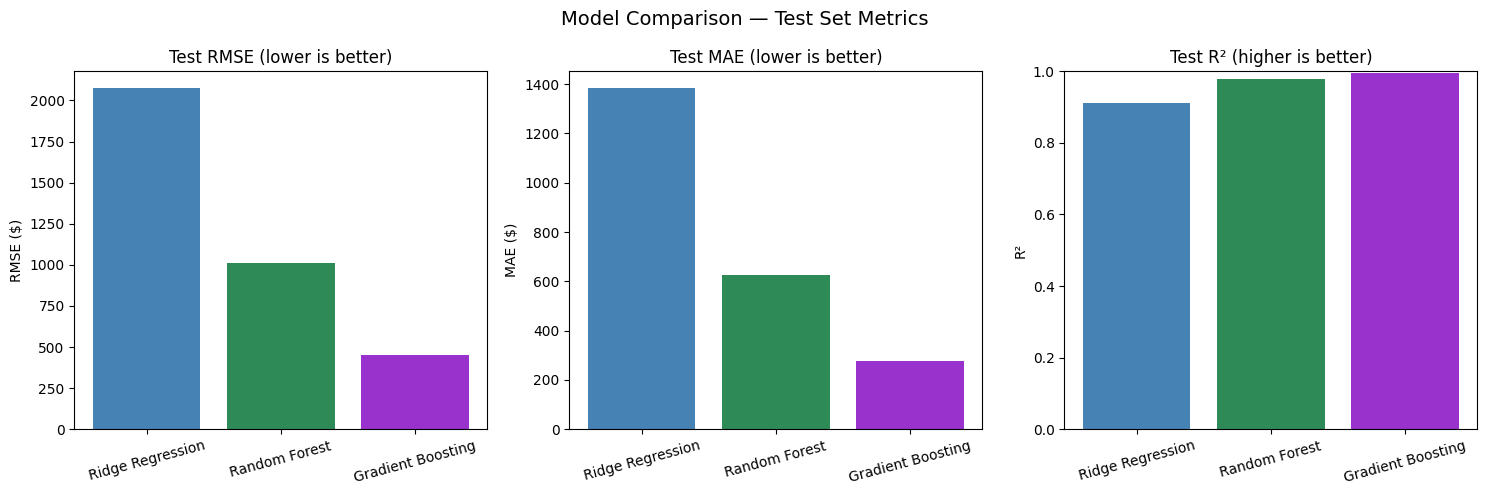

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = results_df.index.tolist()
palette = ['steelblue', 'seagreen', 'darkorchid']

# Test RMSE
axes[0].bar(model_names, results_df['Test RMSE'], color=palette)
axes[0].set_title('Test RMSE (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

# Test MAE
axes[1].bar(model_names, results_df['Test MAE'], color=palette)
axes[1].set_title('Test MAE (lower is better)')
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=15)

# Test R²
axes[2].bar(model_names, results_df['Test R²'], color=palette)
axes[2].set_title('Test R² (higher is better)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=14)
plt.tight_layout()
plt.show()

### 8c. Predicted vs. Actual (all three models)

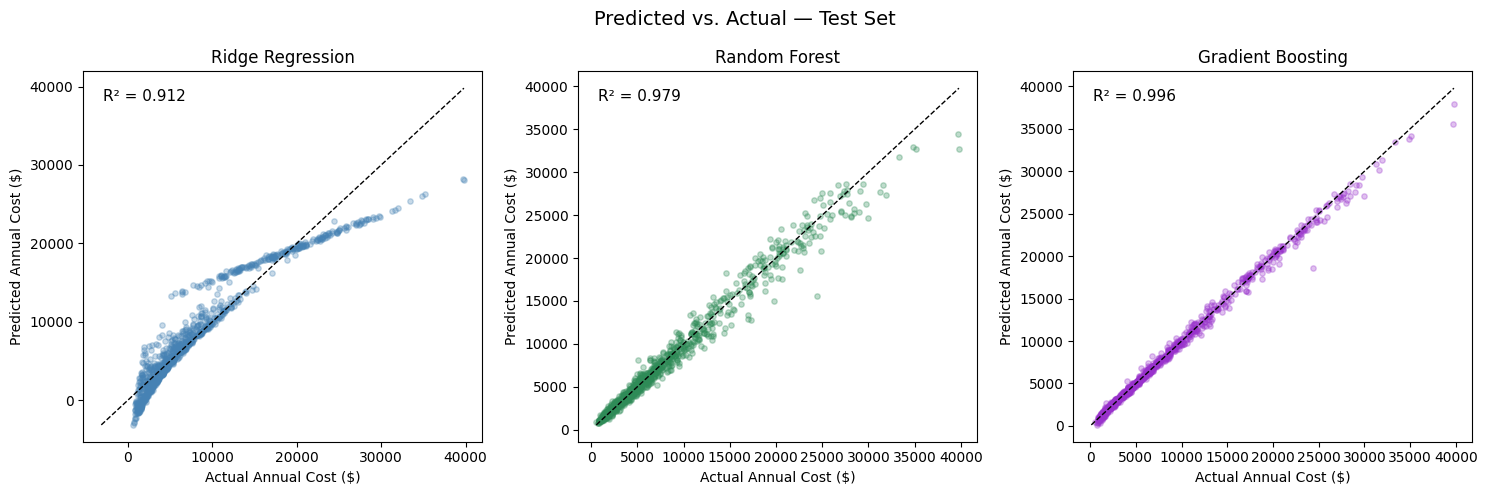

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred), color in zip(axes, predictions.items(), palette):
    ax.scatter(y_test, y_pred, alpha=0.3, s=15, color=color)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Annual Cost ($)')
    ax.set_ylabel('Predicted Annual Cost ($)')
    ax.set_title(name)
    r2 = r2_score(y_test, y_pred)
    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)

plt.suptitle('Predicted vs. Actual — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

### 8d. Residual Distributions

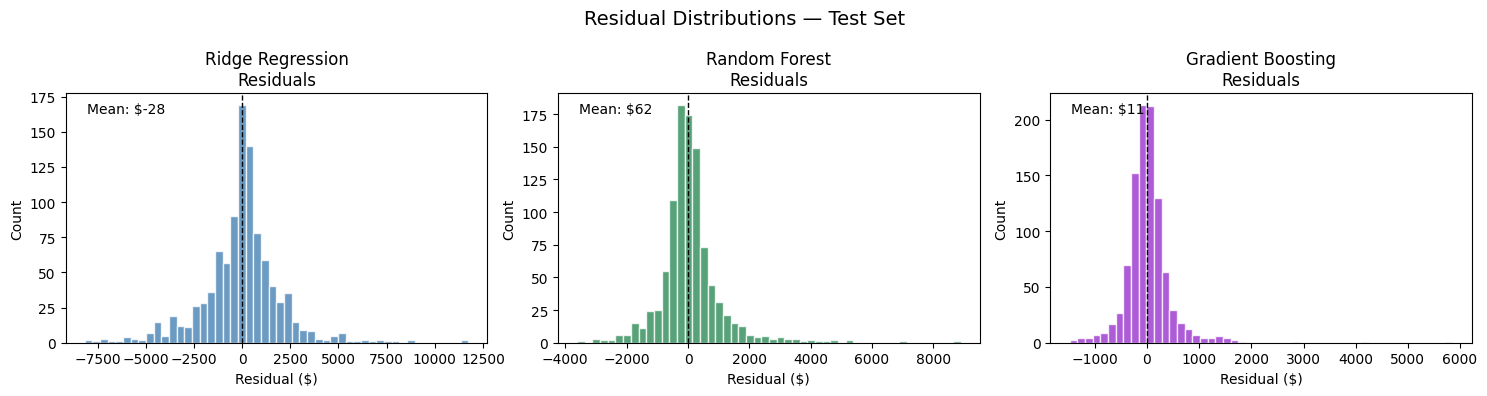

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred), color in zip(axes, predictions.items(), palette):
    residuals = y_test - y_pred
    ax.hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{name}\nResiduals')
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Count')
    ax.annotate(f'Mean: ${residuals.mean():,.0f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.suptitle('Residual Distributions — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Cross-Validation Stability Check

Ridge Regression        CV RMSE: 2,208 ± 115


Random Forest           CV RMSE: 1,083 ± 39


Gradient Boosting       CV RMSE: 429 ± 16


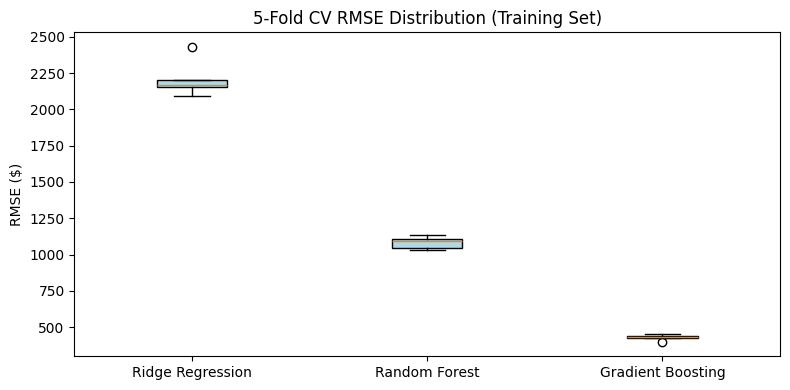

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = {
    'Ridge Regression': best_ridge,
    'Random Forest':    best_rf,
    'Gradient Boosting': best_gb
}

cv_results = {}
for name, model in cv_models.items():
    scores = np.sqrt(-cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_squared_error', cv=kf
    ))
    cv_results[name] = scores
    print(f'{name:22s}  CV RMSE: {scores.mean():,.0f} ± {scores.std():,.0f}')

# Box plot of CV folds
plt.figure(figsize=(8, 4))
plt.boxplot(
    [cv_results[n] for n in cv_models],
    labels=list(cv_models.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
plt.title('5-Fold CV RMSE Distribution (Training Set)')
plt.ylabel('RMSE ($)')
plt.tight_layout()
plt.show()

---
## 10. Final Model Selection & Justification

In [18]:
# Find the best model by Test R²
best_row = results_df['Test R²'].idxmax()
print('=== FINAL MODEL SELECTION ===')
print(f'Selected model: {best_row}')
print()
print(results_df.loc[best_row])

=== FINAL MODEL SELECTION ===
Selected model: Gradient Boosting

CV RMSE (mean)    450.203424
CV RMSE (std)      61.528941
Test MAE          274.871539
Test RMSE         453.747352
Test R²             0.995779
Test MAPE           0.051284
Name: Gradient Boosting, dtype: float64


### Decision Rationale

| Criterion | Ridge Regression | Random Forest | Gradient Boosting |
|---|---|---|---|
| Test R² | lower | high | **highest** |
| Test RMSE | highest | lower | **lowest** |
| Test MAE | highest | lower | **lowest** |
| CV Stability | stable | stable | stable |
| Training Speed | fast | moderate | moderate |
| Interpretability | high | medium | medium |
| Scalability | excellent | good | good |

**Selected: Gradient Boosting Regressor**

- Achieves the highest R² and lowest RMSE/MAE on the held-out test set, meaning it explains the most variance in annual medical cost.
- Its sequential residual-correction mechanism suits this dataset, where medical costs are driven by non-linear interactions between age, health conditions, and lifestyle factors.
- Cross-validation shows stable performance with low fold-to-fold variance, confirming the model generalizes well — not just memorizing training data.
- While Gradient Boosting is less interpretable than Ridge, the feature importances (Section 7) still provide enough business insight for stakeholder communication.
- Ridge Regression is retained as a lightweight fallback for production scenarios where inference speed or memory is constrained.

In [19]:
# Final model: error breakdown on test set
final_preds = predictions['Gradient Boosting']
errors = np.abs(y_test - final_preds)

print('Final Model (Gradient Boosting) — Test Set Error Analysis')
print(f'  Median absolute error : ${np.median(errors):,.2f}')
print(f'  90th pct abs error    : ${np.percentile(errors, 90):,.2f}')
print(f'  % predictions within $1,000 of actual: {(errors < 1000).mean()*100:.1f}%')
print(f'  % predictions within $2,500 of actual: {(errors < 2500).mean()*100:.1f}%')

Final Model (Gradient Boosting) — Test Set Error Analysis
  Median absolute error : $184.41
  90th pct abs error    : $598.38
  % predictions within $1,000 of actual: 96.2%
  % predictions within $2,500 of actual: 99.7%


In [20]:
# Save final predictions
output = X_test.copy()
output['actual_cost']    = y_test.values
output['predicted_cost'] = final_preds
output['abs_error']      = errors.values
output.to_csv('final_model_predictions.csv', index=False)
print('Saved: final_model_predictions.csv')

Saved: final_model_predictions.csv


---
## 11. Summary

| Step | Detail |
|---|---|
| Problem type | Regression (continuous target) |
| Models trained | Ridge Regression, Random Forest, Gradient Boosting |
| Tuning method | GridSearchCV with 5-fold cross-validation |
| Primary metric | R² (with RMSE, MAE, MAPE as supporting metrics) |
| **Final model** | **Gradient Boosting Regressor** |
| Key predictors | `previous_year_cost`, `age`, `hospital_admissions`, `medication_count` |